# Fine-Tuning BERT on IBCM Dataset (Text Classification)

In [16]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib
import torch

In [17]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("IMDB Dataset.csv")
df.head()

# handle missing values
df = df.dropna()

TEXT_COL = 'review'
LABEL_COL = 'sentiment'

# convert labels
df[LABEL_COL] = df[LABEL_COL].map({'negative': 0, 'positive': 1})

# check distribution
print(df[LABEL_COL].value_counts())

Saving IMDB Dataset.csv to IMDB Dataset (1).csv
sentiment
1    25000
0    25000
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

# Split df into train and temp (80% train, 20% temp)
train_df_full, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[LABEL_COL])

# Split temp into validation and test (10% valid, 10% test of original df)
valid_df_full, test_df_full = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df[LABEL_COL])

# Select columns and handle missing values
train_df = train_df_full[[TEXT_COL, LABEL_COL]].dropna().copy()
valid_df = valid_df_full[[TEXT_COL, LABEL_COL]].dropna().copy()
test_df = test_df_full[[TEXT_COL, LABEL_COL]].dropna().copy()

# lowercase
train_df.loc[:, TEXT_COL] = train_df[TEXT_COL].str.lower()
valid_df.loc[:, TEXT_COL] = valid_df[TEXT_COL].str.lower()
test_df.loc[:, TEXT_COL] = test_df[TEXT_COL].str.lower()

# Reduce dataset size (faster training)
train_df = train_df.sample(1000, random_state=42)
valid_df = valid_df.sample(300, random_state=42)

# Convert labels
train_df.loc[:, LABEL_COL] = train_df[LABEL_COL].astype(int)
valid_df.loc[:, LABEL_COL] = valid_df[LABEL_COL].astype(int)
test_df.loc[:, LABEL_COL] = test_df[LABEL_COL].astype(int)

In [19]:
#TOKENIZATION
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_df[TEXT_COL]), truncation=True, padding=True, max_length=64)
valid_encodings = tokenizer(list(valid_df[TEXT_COL]), truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(list(test_df[TEXT_COL]), truncation=True, padding=True, max_length=64)

In [20]:
#DATASET CLASS
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

train_dataset = Dataset(train_encodings, list(train_df[LABEL_COL]))
valid_dataset = Dataset(valid_encodings, list(valid_df[LABEL_COL]))
test_dataset = Dataset(test_encodings, list(test_df[LABEL_COL]))

In [21]:
#MODEL
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
#TRAINING ARGS
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="epoch"
)

In [23]:
#METRICS
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [24]:
#TRAINER
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)


In [25]:
#TRAIN MODEL
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.569545,0.706667,0.653543,0.805825,0.549669


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=125, training_loss=0.6132901611328125, metrics={'train_runtime': 36.0315, 'train_samples_per_second': 27.754, 'train_steps_per_second': 3.469, 'total_flos': 32888881920000.0, 'train_loss': 0.6132901611328125, 'epoch': 1.0})

In [26]:
#TEST EVALUATION
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = test_df[LABEL_COL].values

print("Accuracy:", accuracy_score(labels, preds))
print("Precision, Recall, F1:", precision_recall_fscore_support(labels, preds, average='binary'))

Accuracy: 0.7504
Precision, Recall, F1: (0.8168016194331984, 0.6456, 0.7211796246648794, None)


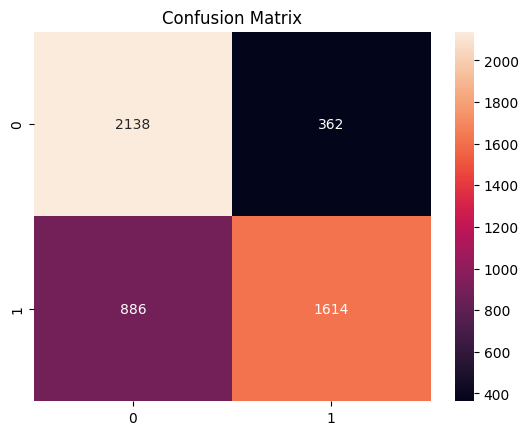

In [27]:
#CONFUSION MATRIX

cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [28]:
#CLASSIFICATION REPORT
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.71      0.86      0.77      2500
           1       0.82      0.65      0.72      2500

    accuracy                           0.75      5000
   macro avg       0.76      0.75      0.75      5000
weighted avg       0.76      0.75      0.75      5000



## Experiments


In [29]:
#FULL BERT
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

preds_full = np.argmax(trainer.predict(test_dataset).predictions, axis=1)
acc_full = accuracy_score(labels, preds_full)

#FREEZE BERT

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for param in model.base_model.parameters():
    param.requires_grad = False

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

preds_frozen = np.argmax(trainer.predict(test_dataset).predictions, axis=1)
acc_frozen = accuracy_score(labels, preds_frozen)

#LAST 2 LAYERS

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

preds_last2 = np.argmax(trainer.predict(test_dataset).predictions, axis=1)
acc_last2 = accuracy_score(labels, preds_last2)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.569545,0.706667,0.653543,0.805825,0.549669


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.651391,0.636667,0.644951,0.634615,0.655629


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

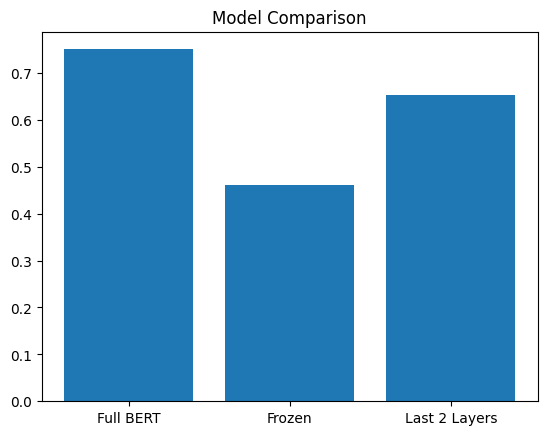

In [30]:
#COMPARISON

models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [acc_full, acc_frozen, acc_last2]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()